In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from wordcloud import WordCloud
from collections import Counter


In [2]:
# Load the dataset
# data = pd.read_csv('political_bias.csv', dtype=str) dont know why this doesnt work 
data = pd.read_csv('political_bias.csv')

In [3]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3458 non-null   object
 1   Link    3458 non-null   object
 2   Text    3397 non-null   object
 3   Source  3458 non-null   object
 4   Bias    3458 non-null   object
dtypes: object(5)
memory usage: 135.2+ KB


In [4]:
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)

Title      0
Link       0
Text      61
Source     0
Bias       0
dtype: int64


In [5]:
# Drop rows with any null (NaN) values
data = data.dropna()

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3397 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3397 non-null   object
 1   Link    3397 non-null   object
 2   Text    3397 non-null   object
 3   Source  3397 non-null   object
 4   Bias    3397 non-null   object
dtypes: object(5)
memory usage: 159.2+ KB


In [6]:
# Drop rows where 'Text' column contains 'Error fetching article'
data = data[data['Text'] != 'Error fetching article']

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2765 non-null   object
 1   Link    2765 non-null   object
 2   Text    2765 non-null   object
 3   Source  2765 non-null   object
 4   Bias    2765 non-null   object
dtypes: object(5)
memory usage: 129.6+ KB


In [7]:
# Clean the 'Text' column to fix encoding issues and remove unwanted characters
def fix_encoding_and_special_chars(text):
    # Fix common encoding issues
    text = text.replace('â€™', '').replace('â€œ', '"').replace('â€', '"').replace('â€™','"').replace('â€˜','"')  # Replace known encoding issues
    
    # Remove special characters using regular expression (keeps only letters, numbers, and spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    return text

# Apply the function to clean the cols
data['Title'] = data['Title'].apply(fix_encoding_and_special_chars)
data['Text'] = data['Text'].apply(fix_encoding_and_special_chars)
data['Source'] = data['Source'].apply(fix_encoding_and_special_chars)
data['Bias'] = data['Bias'].apply(fix_encoding_and_special_chars)

# Convert the data to strings 
data['Title'] = data['Title'].astype('string')
data['Text'] = data['Text'].astype('string')
data['Link'] = data['Link'].astype('string')
data['Source'] = data['Source'].astype('string')
data['Bias'] = data['Bias'].astype('string')

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2765 non-null   string
 1   Link    2765 non-null   string
 2   Text    2765 non-null   string
 3   Source  2765 non-null   string
 4   Bias    2765 non-null   string
dtypes: string(5)
memory usage: 129.6 KB


In [8]:
# Show the first few rows of the dataset
data.head()

,Title,Link,Text,Source,Bias
0,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,TheDispatch,lean right
1,Why Shrubland Makes Southern Californias Wildf...,https://thedispatch.com/newsletter/techne/why-...,Welcome back to Techne In Star Trek writers go...,TheDispatch,lean right
2,Los Angeles Destruction Was Fueled by Bad Poli...,https://thedispatch.com/newsletter/capitolism/...,As fire still rages in the Los Angeles area Iv...,TheDispatch,lean right
3,Acquiring Greenland Is a Good Idea Threatening...,https://thedispatch.com/article/acquiring-gree...,Whether it was Will Rogers or Tony Soprano the...,TheDispatch,lean right
4,Assessing Trumps Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,Happy Friday If anyone was wondering Belgiums ...,TheDispatch,lean right


In [9]:
# Summary statistics of numerical columns (if any)
data.describe()

,Title,Link,Text,Source,Bias
count,2765,2765,2765,2765,2765
unique,2511,2280,2434,21,5
top,Trumps Supposed Unity Message Is a Gloating Th...,https://www.thenation.com/article/politics/dem...,A new bill in Mississippi could turn bounty hu...,Alternet,left
freq,7,7,5,596,1376


In [10]:
# noticed that not all rows are unique, so we will drop duplicates
data = data.drop_duplicates(subset='Title', keep='first')
data = data.drop_duplicates(subset='Text', keep='first')
data = data.drop_duplicates(subset='Link', keep='first')

In [11]:
# Verify by checking the data info
data.describe()

,Title,Link,Text,Source,Bias
count,2224,2224,2224,2224,2224
unique,2224,2224,2224,21,5
top,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,Alternet,left
freq,1,1,1,483,1150


In [12]:
# Checking the distribution of the 'Bias' column
bias_counts = data['Bias'].value_counts()
print(bias_counts)
# over representation of left bias

Bias
left          1150
right          382
lean left      305
center         202
lean right     185
Name: count, dtype: Int64


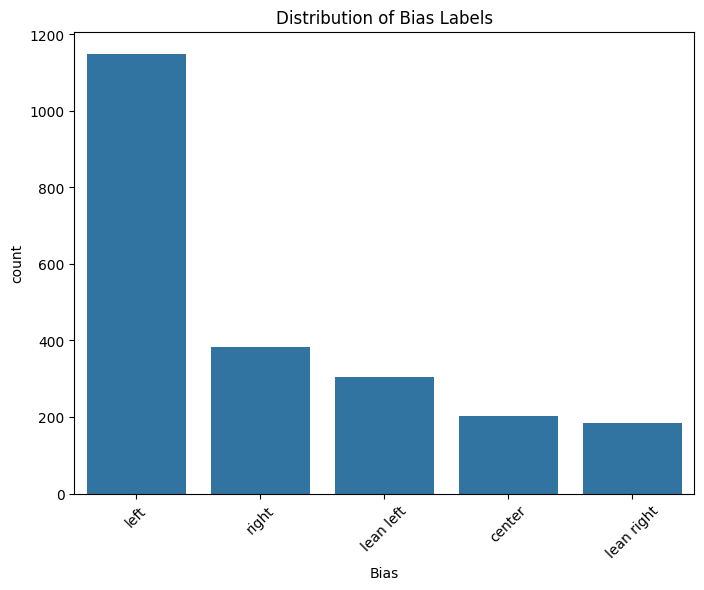

In [13]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Bias', order=data['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)
plt.show()

In [14]:
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords
nltk.download('stopwords')

# Get the set of English stopwords
stop_words = set(stopwords.words('english'))

# Updated clean_text function to remove punctuation and stopwords
def clean_text(text):
    text = text.lower()  # Convert text to lowercase
    text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Split text into words
    text = ' '.join([word for word in words if word not in stop_words]) # Remove stopwords
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# Apply the clean_text function to the 'Text' column
data['cleaned_text'] = data['Text'].apply(clean_text)

# Most common words (excluding stopwords)
words = ' '.join(data['cleaned_text']).split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)

# Display the 20 most common words
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
common_words_df

,Word,Frequency
0,trump,9649
1,said,8341
2,president,4765
3,us,4116
4,people,3468
5,trumps,3419
6,would,3336
7,also,3076
8,one,2862
9,new,2656


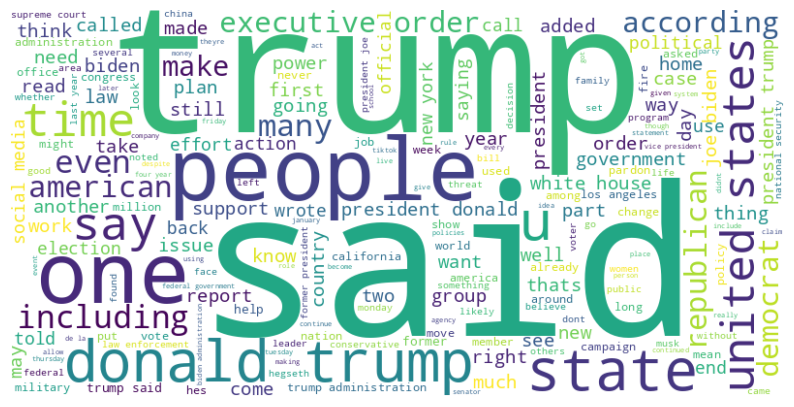

In [16]:
# Generate a wordcloud
text = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


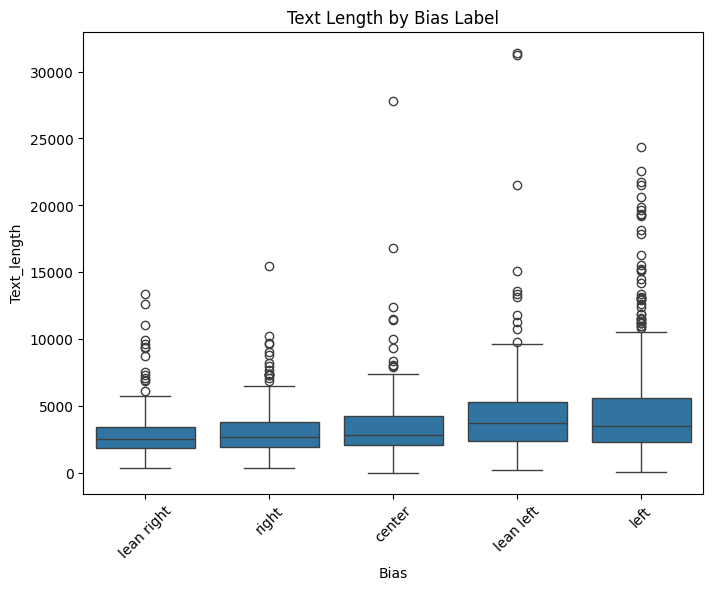

In [17]:
# Investigating length of articles by bias
data['Text_length'] = data['Text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='Text_length')
plt.title('Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

Source
Alternet                    483
Apnews                      390
BreitBart                   221
NewYorkPost                 132
Huffpost                    128
usatoday                     97
reason                       88
StraightArrowNews            81
abcnews                      77
npr                          75
IndependentJournalReview     72
MotherJones                  59
TheDailyBeast                59
nbcnews                      56
TheFederalist                40
TheFreePress                 36
BlazeMedia                   35
cnbc                         33
TheNation                    31
TheDispatch                  17
TheWashingtonFreeBeacon      14
Name: count, dtype: Int64


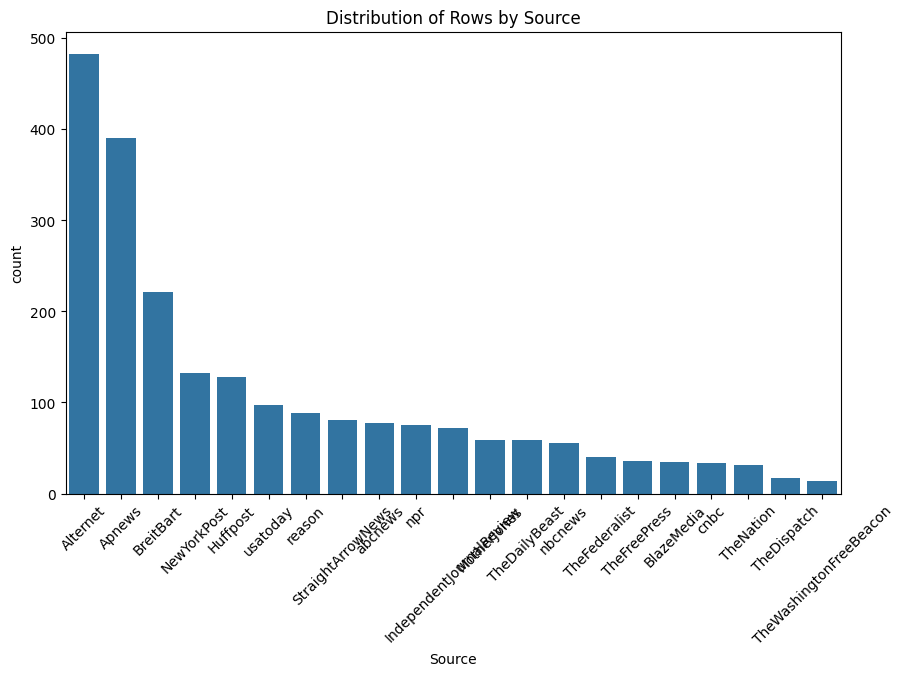

In [18]:
## check distribution of news sources
source_counts = data['Source'].value_counts()

# Print the distribution
print(source_counts)

# Plot the distribution using a bar plot
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Source', order=source_counts.index)
plt.title('Distribution of Rows by Source')
plt.xticks(rotation=45)
plt.show()

Bias                      center  lean left  lean right  left  right
Source                                                              
Alternet                       0          0           0   483      0
Apnews                         0          0           0   390      0
BreitBart                      0          0           0     0    221
NewYorkPost                    0          0         132     0      0
Huffpost                       0          0           0   128      0
usatoday                       0         97           0     0      0
reason                        88          0           0     0      0
StraightArrowNews             81          0           0     0      0
abcnews                        0         77           0     0      0
npr                            0         75           0     0      0
IndependentJournalReview       0          0           0     0     72
MotherJones                    0          0           0    59      0
TheDailyBeast                  0  

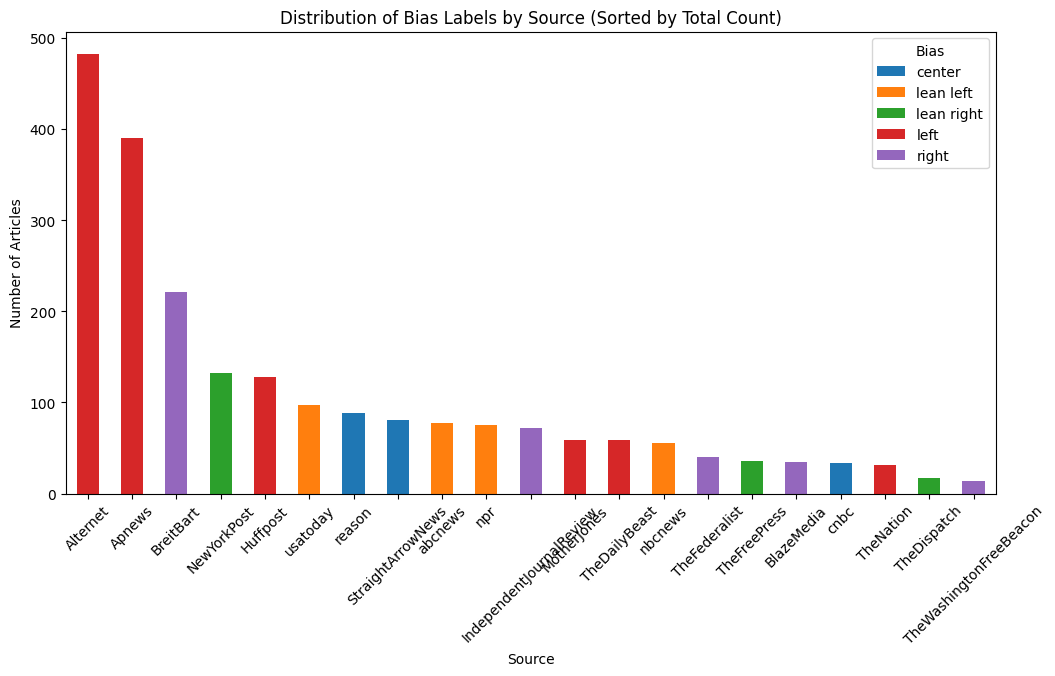

In [20]:
# Group by 'Source' and 'Bias' and get the count for each combination
bias_distribution_by_source = data.groupby(['Source', 'Bias']).size().unstack(fill_value=0)

# Sum the counts for each source and sort by the total count
bias_distribution_by_source['Total'] = bias_distribution_by_source.sum(axis=1)
bias_distribution_by_source = bias_distribution_by_source.sort_values(by='Total', ascending=False)

# Drop the 'Total' column from the plot
bias_distribution_by_source.drop('Total', axis=1, inplace=True)

# Print the sorted distribution
print(bias_distribution_by_source)

# Plot the distribution using a stacked bar plot
bias_distribution_by_source.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Bias Labels by Source (Sorted by Total Count)')
plt.xlabel('Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.legend(title='Bias')
plt.show()

Bias                      center  lean left  lean right   left  right
Source                                                               
Alternet                     0.0        0.0         0.0  100.0    0.0
TheFederalist                0.0        0.0         0.0    0.0  100.0
reason                     100.0        0.0         0.0    0.0    0.0
npr                          0.0      100.0         0.0    0.0    0.0
nbcnews                      0.0      100.0         0.0    0.0    0.0
cnbc                       100.0        0.0         0.0    0.0    0.0
abcnews                      0.0      100.0         0.0    0.0    0.0
TheWashingtonFreeBeacon      0.0        0.0         0.0    0.0  100.0
TheNation                    0.0        0.0         0.0  100.0    0.0
TheFreePress                 0.0        0.0       100.0    0.0    0.0
TheDispatch                  0.0        0.0       100.0    0.0    0.0
Apnews                       0.0        0.0         0.0  100.0    0.0
TheDailyBeast       

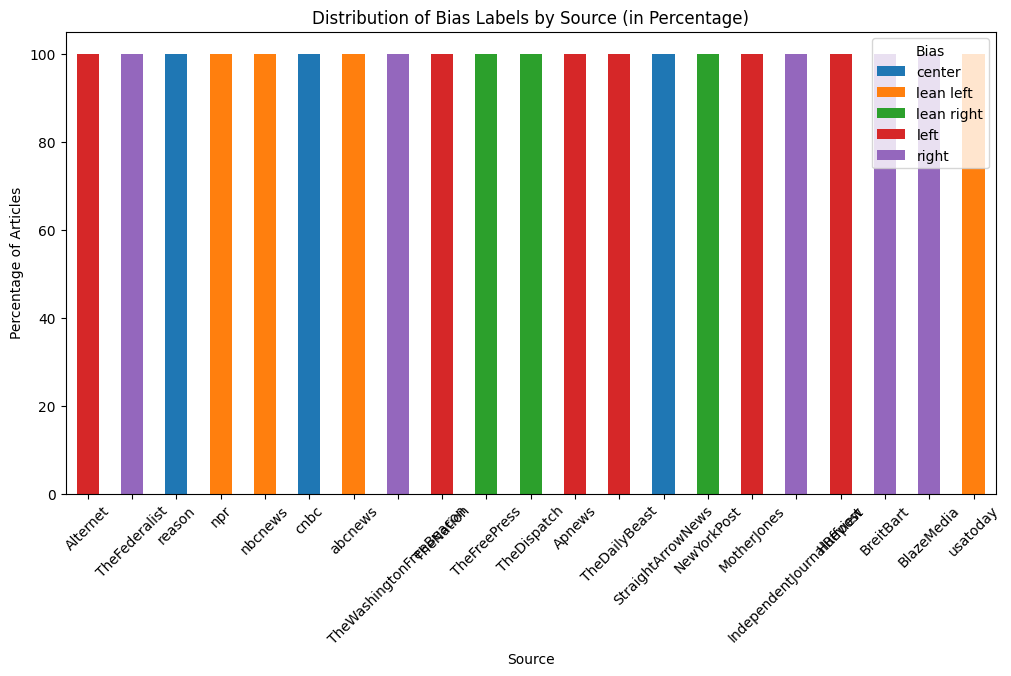

In [ ]:
# Group by 'Source' and 'Bias' and get the count for each combination
bias_distribution_by_source = data.groupby(['Source', 'Bias']).size().unstack(fill_value=0)

# Normalize the counts by dividing by the row sums (to get percentages)
bias_distribution_by_source = bias_distribution_by_source.div(bias_distribution_by_source.sum(axis=1), axis=0) * 100

# Sort by the total percentage (optional, to maintain consistency)
bias_distribution_by_source['Total'] = bias_distribution_by_source.sum(axis=1)
bias_distribution_by_source = bias_distribution_by_source.sort_values(by='Total', ascending=False)

# Drop the 'Total' column from the plot
bias_distribution_by_source.drop('Total', axis=1, inplace=True)

# Print the normalized distribution
print(bias_distribution_by_source)

# Plot the distribution using a stacked column chart in percentages
bias_distribution_by_source.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Bias Labels by Source (in Percentage)')
plt.xlabel('Source')
plt.ylabel('Percentage of Articles')
plt.xticks(rotation=45)
plt.legend(title='Bias')
plt.show()

# all sources produce only one type of bias, hence source is a strong predictor of bias